# 캘리포니아 주택가격 Dataset

**캘리포니아 주택 가격(California Housing) 데이터셋**은 머신러닝에서 회귀(Regression) 문제를 연습할 때 가장 널리 사용되는 대표적인 데이터셋 중 하나입니다.

이 데이터셋은 **1990년 미국 인구조사(Census)** 데이터를 바탕으로 하며, 캘리포니아의 각 조사 구역(Block Group, 대략 600명~3,000명이 거주하는 최소 지리 단위)별 특징과 주택 가격 중간값을 포함하고 있습니다.

### 1. 데이터셋 크기 및 구조 (Shape)

* **샘플 수(행, Instances):** $20,640$개
* **특성 수(열, Attributes):** $8$개의 수치형 독립 변수
* **타깃 변수(Target):** $1$개의 연속형 종속 변수 (주택 가격)
* **결측치(Missing Values):** 존재하지 않음 (모든 데이터가 깔끔하게 채워져 있습니다.)

### 2. 독립 변수 (Features, $8$개)

모델이 주택 가격을 예측하기 위해 사용하는 8개의 입력 데이터 항목입니다.

1. **`MedInc` (Median Income):** 해당 구역 가구들의 **소득 중간값**
* 단위가 만 달러($10,000) 단위로 조정되어 있습니다. (예: `5.0`인 경우 $50,000 달러를 의미)


2. **`HouseAge` (Median House Age):** 해당 구역 주택들의 **연식 중간값** (오래된 정도)
3. **`AveRooms` (Average Rooms):** 가구당 **평균 방 개수**
4. **`AveBedrms` (Average Bedrooms):** 가구당 **평균 침실 개수**
5. **`Population` (Population):** 해당 구역의 **총 인구수**
6. **`AveOccup` (Average Occupancy):** 가구당 **평균 구성원 수**
7. **`Latitude` (Latitude):** 구역의 **위도** (지리적 위치)
8. **`Longitude` (Longitude):** 구역의 **경도** (지리적 위치)


### 3. 종속 변수 (Target, $1$개)

모델이 최종적으로 맞춰야 하는 예측 대상입니다.

* **`MedHouseVal` (Median House Value):** 해당 구역의 **주택 가격 중간값**
* 단위는 10만 달러($100,000)입니다. (예: 타깃 값이 `2.5`라면 해당 구역의 주택 가격 중간값은 $250,000 달러를 의미합니다.)
* 실제 데이터에서는 50만 달러($5.0$) 이상의 주택 가격이 모두 `5.0`으로 상한선(Capping) 처리되어 있는 특징이 있습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. 데이터 불러오기
california = fetch_california_housing(as_frame=True)

# 2. DataFrame 생성 (상위 5개 행 확인)
df = california.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
# 요약 정보 확인 (결측치 및 데이터 타입 확인)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [2]:
# 각 피처들의 요약 통계량 확인
display(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# 데이터 로드 및 피처 이름 출력
california = fetch_california_housing(as_frame=True)
print("Features:", california.feature_names)

X = california.data
y = california.target

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [8]:
from sklearn.model_selection import train_test_split

# 학습용, 테스트용 데이터 8:2 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# alpha 후보군 설정 및 점수 저장용 리스트
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores = []
test_scores = []

# 반복문으로 alpha별 스케일링 + Ridge 학습 수행
for alpha in alpha_list:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

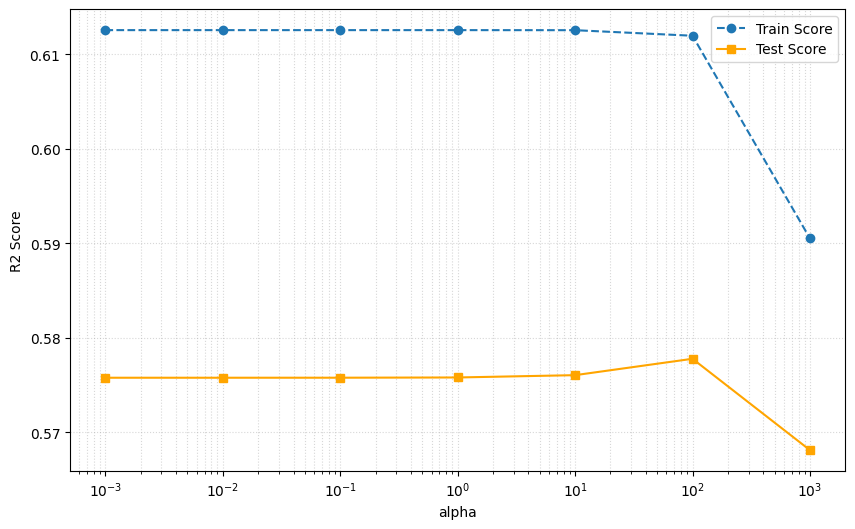

In [10]:
# alpha 탐색 결과 그래프 그리기 (로그 스케일 적용)
plt.figure(figsize=(10, 6))
plt.plot(alpha_list, train_scores, label='Train Score', marker='o', linestyle='--')
plt.plot(alpha_list, test_scores, label='Test Score', marker='s', color='orange')

plt.xscale('log') 
plt.xlabel('alpha')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()

In [11]:
# 그래프를 보고 정한 최적 alpha(예: 10)로 최종 학습
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
])
best_pipe.fit(X_train, y_train)

# 가중치(coef_) 추출 후 중요도 순으로 정렬
coef_df = pd.DataFrame({
    'Feature': california.feature_names,
    'Coefficient': best_pipe.named_steps['ridge'].coef_
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs', ascending=False).drop(columns=['Abs'])

# 상위 특성 확인
display(coef_df.reset_index(drop=True))

,Feature,Coefficient
0,Latitude,-0.889384
1,Longitude,-0.862199
2,MedInc,0.853814
3,AveBedrms,0.336750
4,AveRooms,-0.292412
5,HouseAge,0.123316
6,AveOccup,-0.040867
7,Population,-0.002055


In [ ]:
import plotly.express as px

# 1,000개 샘플링
df_sample = df.sample(n=1000, random_state=42)

# scatter_mapbox 대신 'scatter_map' 사용
fig = px.scatter_map(
    df_sample, 
    lat="Latitude", 
    lon="Longitude", 
    color="MedHouseVal",      
    size="Population",        
    color_continuous_scale=px.colors.cyclical.IceFire, 
    size_max=15,              
    zoom=5,                   
    map_style="open-street-map", # mapbox_style 대신 'map_style' 사용
    title="California Housing Prices",
    width=900,
    height=600
)

# 지도 출력
fig.show()

C:\Users\student\AppData\Local\Temp\ipykernel_12220\2264292491.py:7: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
